📊 Klasteryzacja klientów na podstawie danych Mall_Customers z użyciem KMeans

🔧 Blok 1: Import bibliotek

In [24]:
# Importujemy niezbędne biblioteki:
import pandas as pd            # do wczytywania i obróbki danych
import numpy as np             # operacje numeryczne
import matplotlib.pyplot as plt  # wykresy
import seaborn as sns            # zaawansowana wizualizacja
from google.colab import files
from sklearn.cluster import KMeans      # algorytm KMeans
from sklearn.preprocessing import StandardScaler  # skalowanie danych
import os

Załadowano główne biblioteki: pandas i numpy — do przetwarzania danych, matplotlib i seaborn — do wizualizacji, scikit-learn — do klastrowania i normalizacji danych.

📁 Blok 2: Pobieranie i wstępna analiza danych

In [26]:
# Interaktywny wybór pliku CSV z komputera
uploaded = files.upload()

# Wyświetlanie pierwszych wierszy tabeli
print(df.head())

# Ogólne informacje o danych
print(df.info())

Saving Mall_Customers.csv to Mall_Customers (3).csv
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None

Dane zawierają 200 rekordów dotyczących klientów. Zawierają one cechy liczbowe (wiek, roczny dochód, wynik wydatków) oraz cechy kategoryczne (płeć). Do klasteryzacji wykorzystamy cechy liczbowe.

🎨 Blok 3: Wizualizacja rozkładu danych

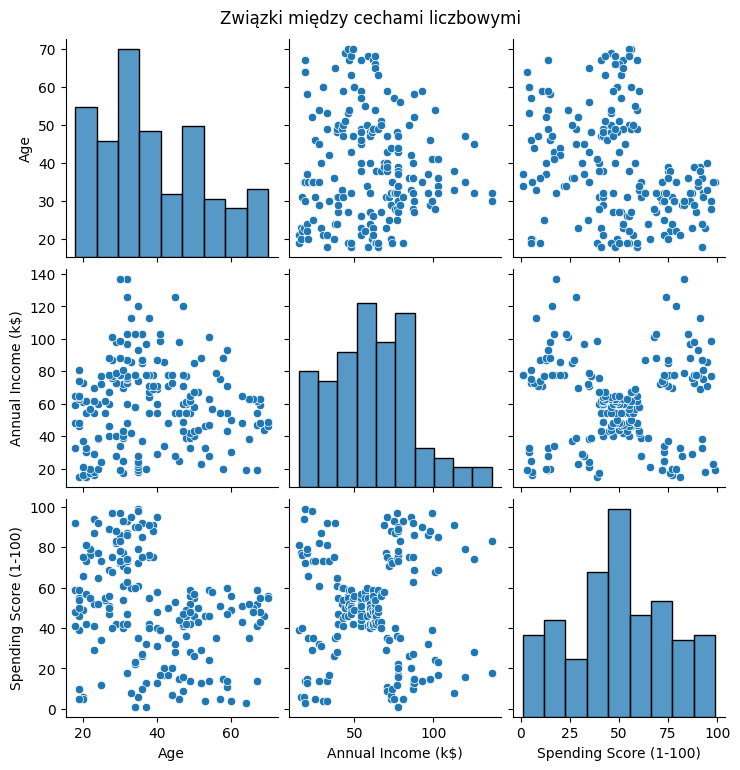

In [27]:
# Zbudujmy wykres par dla cech liczbowych
sns.pairplot(df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']])
plt.suptitle("Związki między cechami liczbowymi", y=1.02)
plt.show()

Widzimy, że wskaźniki Annual Income i Spending Score dają dobrą możliwość wizualnego podziału grup klientów — są to dobrzy kandydaci do klastrowania.

🧹 Blok 4: Przygotowanie danych

In [28]:
# Wybieramy dwa kluczowe cechy do klasteryzacji
X = df[['Annual Income (k$)', 'Spending Score (1-100)']].copy()

# Standaryzacja cech
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Wybraliśmy dwie najbardziej informacyjne cechy. Standaryzacja pozwala uniknąć dominacji jednej cechy nad drugą podczas obliczania odległości w KMeans.

📉 Blok 5: Określenie optymalnej liczby klastrów (metoda łokcia)

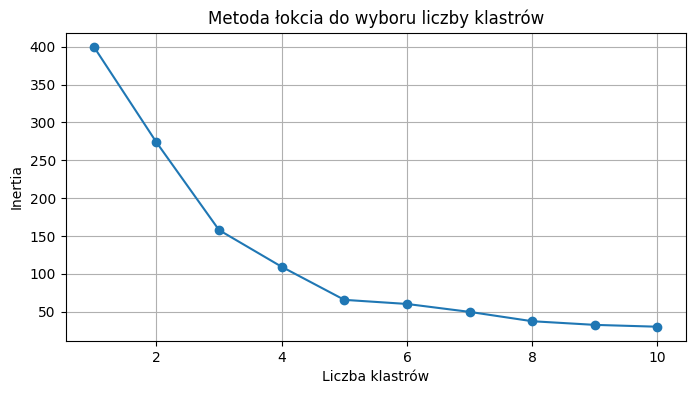

In [29]:
# Obliczmy metrykę „inertia” dla różnych wartości k
inertia = []
for k in range(1, 11):
    km = KMeans(n_clusters=k, init='k-means++', random_state=42)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

# Wizualizujemy metodę łokcia
plt.figure(figsize=(8, 4))
plt.plot(range(1, 11), inertia, marker='o')
plt.title('Metoda łokcia do wyboru liczby klastrów')
plt.xlabel('Liczba klastrów')
plt.ylabel('Inertia')
plt.grid()
plt.show()

„Łokieć” wykresu zazwyczaj wskazuje optymalną liczbę klastrów. W naszym przypadku wartość ta wynosi około 5 — po tym punkcie następuje punkt przegięcia, a spadek staje się mniej znaczący.

⚙️ Blok 6: Nauka modelu K średnich

In [30]:
# Trenujemy model z 5 klastrami
k = 5
kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
y_kmeans = kmeans.fit_predict(X_scaled)

# Dodajemy informacje o przynależności do klastra do ramki danych
df['Cluster'] = y_kmeans

Model został wyszkolony, każdemu klientowi przypisano klaster od 0 do 4. Następnie wizualizujemy uzyskane grupy.

📊 Blok 7: Wizualizacja klastrów

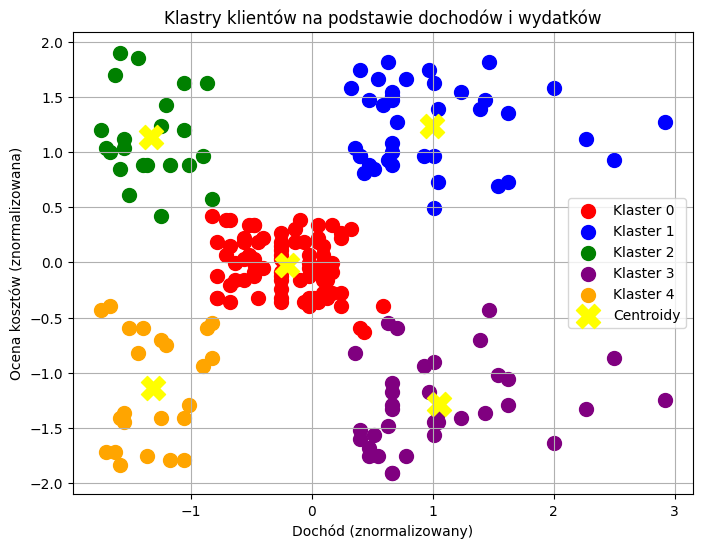

In [34]:
# Wizualizacja klastrów i centroidów
plt.figure(figsize=(8, 6))
colors = ['red', 'blue', 'green', 'purple', 'orange']
for i in range(k):
    plt.scatter(X_scaled[y_kmeans == i, 0], X_scaled[y_kmeans == i, 1],
                s=100, c=colors[i], label=f'Klaster {i}')

# Centroidy
centroids = kmeans.cluster_centers_
plt.scatter(centroids[:, 0], centroids[:, 1], s=300, c='yellow', label='Centroidy', marker='X')

plt.title('Klastry klientów na podstawie dochodów i wydatków')
plt.xlabel('Dochód (znormalizowany)')
plt.ylabel('Ocena kosztów (znormalizowana)')
plt.legend()
plt.grid()
plt.show()

Na wykresie wyraźnie widać podział klientów według zachowań: jedni mają wysokie dochody i niskie wydatki, inni mają niskie dochody, ale wysokie wydatki itp. Klastry są dość dobrze rozdzielone.

📄 Blok 8: Przeglądanie wyników

In [35]:
# Wyświetlanie pierwszych wierszy z przypisanymi klastrami
print(df[['CustomerID', 'Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)', 'Cluster']].head())

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)  \
0           1    Male   19                  15                      39   
1           2    Male   21                  15                      81   
2           3  Female   20                  16                       6   
3           4  Female   23                  16                      77   
4           5  Female   31                  17                      40   

   Cluster  
0        4  
1        2  
2        4  
3        2  
4        4  


Teraz można wykorzystać informacje o klastrach, na przykład do celów marketingowych — kierować reklamy do grup klientów o różnych zachowaniach.